# Your solved SQD notebook

**Read this as a guided experiment.** Try to predict each answer, then run the cell and compare with the explanation underneath. All 12 exercises are filled in; the plots and tables come from local execution.

Start with Parts 2–3 (electron seats and the selected Hamiltonian), then Part 6 (the official solver). Parts 7–8 let you see what changing geometry, noise and batch size actually does.

Adapted from `Rishabh_tutorial_sqd_masterclass.ipynb`. Corrections include PySCF determinant order, genuine amplitude scaling, honest failure handling, controlled batching and qualified theoretical claims. No credentials are read.

## Sample-based quantum diagonalization: the worked masterclass
We use H2 and H4 in the STO-3G basis to learn orbital encoding, symmetry filtering, selected Hamiltonians and the official SQD solver. The final experiments vary geometry, synthetic readout noise and batching.

SQD/QSCI are closely related sampling-and-diagonalization approaches. This notebook uses the official SQD configuration-recovery workflow for its larger example. Its small molecular spaces make independent checks possible; they do not demonstrate computational advantage.


## Part 0: Run the solved notebook
Use the repository's Python 3.12 environment: `uv sync --locked`, then `uv run jupyter lab`. Choose its Python kernel and run cells in order. Dependencies are locked in `pyproject.toml` / `uv.lock`; installation is separate from calculation.

**Everything here runs locally.** Aer produces ideal finite-shot samples; the noise exercise adds synthetic readout bit flips. No API key or hardware job is used.

The source worksheet is credited in the opening note. Answers and corrections are included throughout; your original exercise copy stays available for practice.


In [1]:
# Environment: no package installation or hardware submission inside a cell.
import math
import itertools
import time
import warnings
from functools import lru_cache
from importlib.metadata import version
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import XXPlusYYGate
from qiskit_aer import AerSimulator
from qiskit.primitives.containers import BitArray
from qiskit.quantum_info import Statevector
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
import pyscf
from pyscf import gto, scf, ao2mo, fci, cc, lib
from qiskit_addon_sqd.counts import bit_array_to_arrays
from qiskit_addon_sqd.subsampling import postselect_by_hamming_right_and_left
from qiskit_addon_sqd.configuration_recovery import recover_configurations
from qiskit_addon_sqd.fermion import diagonalize_fermionic_hamiltonian
import ffsim
# Some macOS wheels have no OpenMP. Aer is also explicitly limited to one thread.
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='OpenMP is not available.*', category=UserWarning)
    lib.num_threads(1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Local simulator environment')
for package in ('qiskit', 'qiskit-aer', 'qiskit-addon-sqd', 'ffsim', 'pyscf'):
    print(f'{package}: {version(package)}')


Local simulator environment
qiskit: 2.5.2
qiskit-aer: 0.17.2
qiskit-addon-sqd: 0.13.1
ffsim: 0.0.83
pyscf: 2.14.0


## Part 1: What SQD changes
VQE estimates a prepared state's energy and adjusts circuit parameters. Molecular Hamiltonians can have many Pauli terms, with measurements grouped when compatible. Their number alone does not determine shot cost; coefficients, variances, grouping and desired precision matter.

SQD measures occupation strings in the computational **Z basis**, uses them to select a determinant subspace, and computes the Hamiltonian matrix elements classically. It then solves the ordinary eigenvalue problem $H_S c=Ec$ because these determinants are orthonormal.

| Step | What happens |
|---|---|
| Circuit sampling | Suggest electronic configurations |
| Filtering / recovery | Enforce known electron counts |
| Projection | Keep the Hamiltonian within selected configurations |
| Diagonalization | Find the lowest-energy combination in that space |

With an exact projected Hamiltonian and converged solve, the energy is at least the exact ground energy in the same physical sector. SQD shifts work to classical computation; it does not make that work free or guarantee useful quantum sampling.

### Exercise 1 — solved
**Computational Z basis.** We measure which orbitals are occupied. Off-diagonal Hamiltonian elements are evaluated classically, so we do not separately measure every Pauli expectation to obtain the selected energy.

**Before proceeding:** predict how many physical arrangements exist for two alpha and two beta electrons in four spatial orbitals.


## 🧬 Part 2: Representing Molecules as Bitstrings

To understand how SQD works on molecular systems, we use the intuitive **"Electrons in Seats"** model.

### 1. Spatial Orbitals as "Seats"
* Think of a molecule's spatial orbitals as a numbered row of seats: $0, 1, 2, \dots, M-1$.
* In each seat, at most **two electrons** can sit (Pauli exclusion principle):
  * One spin-up electron ($\alpha$, labeled with a blue arrow $\uparrow$)
  * One spin-down electron ($\beta$, labeled with a red arrow $\downarrow$)
* A specific arrangement of electrons in these seats is called a **Slater Determinant** $|D\rangle$.

### 2. The Jordan-Wigner Bitstring Convention
In quantum computation, we represent these configurations as binary bitstrings:
* **Qubits $0$ to $M-1$**: carry the spin-up ($\alpha$) electrons.
* **Qubits $M$ to $2M-1$**: carry the spin-down ($\beta$) electrons.
* The standard convention in Qiskit and SQD packs them together as:
  $$\text{bitstring} = \boldsymbol{\beta}\text{\_bits} + \boldsymbol{\alpha}\text{\_bits}$$
  *(where orbital $0$ is the rightmost bit of each half).*

### 3. Minimal Basis (STO-3G) Systems:
* **$H_2$ in Minimal Basis (STO-3G)**:
  * $M = 2$ spatial orbitals $\to$ **4 qubits** (2 spin-orbitals for $\alpha$, 2 for $\beta$).
  * 2 electrons ($N_\alpha = 1, N_\beta = 1$).
  * Hartree-Fock state: $\alpha = \text{"01"}$, $\beta = \text{"01"}$, packed bitstring = $\text{"0101"}$.
* **$H_4$ in Minimal Basis (STO-3G)**:
  * $M = 4$ spatial orbitals $\to$ **8 qubits** (4 spin-orbitals for $\alpha$, 4 for $\beta$).
  * 4 electrons ($N_\alpha = 2, N_\beta = 2$).
  * Hartree-Fock state: electrons doubly occupy orbitals 0 and 1: $\alpha = \text{"0011"}$, $\beta = \text{"0011"}$, packed bitstring = $\text{"00110011"}$.

Let's run a visualizer to draw these orbital-ladder configurations!


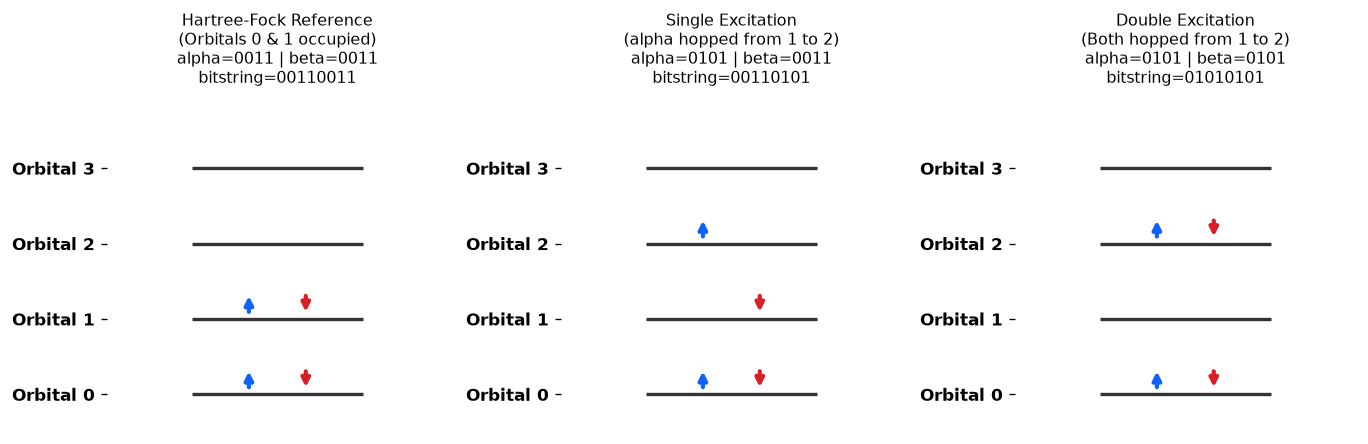

In [2]:
# Code Cell 2.1: Orbital Ladder Visualizer
def draw_molecular_configuration(alpha: str, beta: str, ax=None, title=""):
    """
    Draw an orbital-ladder diagram of a molecular electron configuration.
    alpha and beta are binary strings (e.g. '0011'), where orbital 0 is the rightmost bit.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.5, 3.5))
    norb = len(alpha)
    for i in range(norb):
        # Draw horizontal rung for orbital i
        ax.hlines(i, -0.3, 0.3, color="#333333", lw=2)
        # Check alpha occupancy (reading right-to-left: orbital i is index norb - 1 - i)
        if alpha[norb - 1 - i] == "1":
            ax.annotate("", (-0.1, i + 0.35), (-0.1, i + 0.05),
                        arrowprops=dict(arrowstyle="-|>", color="#0f62fe", lw=2.5))
        # Check beta occupancy
        if beta[norb - 1 - i] == "1":
            ax.annotate("", (0.1, i + 0.05), (0.1, i + 0.35),
                        arrowprops=dict(arrowstyle="-|>", color="#da1e28", lw=2.5))

    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.5, norb)
    ax.set_yticks(range(norb))
    ax.set_yticklabels([f"Orbital {i}" for i in range(norb)], fontsize=10, fontweight="bold")
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(f"{title}\nalpha={alpha} | beta={beta}\nbitstring={beta+alpha}", fontsize=9.5)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8))
draw_molecular_configuration("0011", "0011", axes[0], "Hartree-Fock Reference\n(Orbitals 0 & 1 occupied)")
draw_molecular_configuration("0101", "0011", axes[1], "Single Excitation\n(alpha hopped from 1 to 2)")
draw_molecular_configuration("0101", "0101", axes[2], "Double Excitation\n(Both hopped from 1 to 2)")
plt.tight_layout()
plt.show()

### ✏️ Exercise 2: Writing Bitstrings for Molecular Configurations ($H_4$)

Now it is your turn to practice writing bitstrings for specific molecular electron arrangements in the minimal basis $H_4$ molecule ($M = 4$ spatial orbitals, 4 electrons: $N_\alpha = 2, N_\beta = 2$)!

Remember the Jordan-Wigner rules for 4 spatial orbitals (numbered $0, 1, 2, 3$):
1. **$\alpha$ string** has length 4: orbital 0 is the rightmost character (`alpha[3]`), orbital 3 is the leftmost (`alpha[0]`).
2. **$\beta$ string** has length 4: orbital 0 is the rightmost character (`beta[3]`), orbital 3 is the leftmost (`beta[0]`).
3. **Packed Jordan-Wigner bitstring** is `beta + alpha` (length 8).

Complete the code cell below for the following 4-electron configurations:
* **State A**: Hartree-Fock ground state ($\alpha$ in orbitals 0 and 1; $\beta$ in orbitals 0 and 1).
* **State B**: Single excitation ($\alpha$ in orbitals 1 and 2; $\beta$ in orbitals 0 and 1).
* **State C**: Double excitation ($\alpha$ in orbitals 0 and 3; $\beta$ in orbitals 0 and 3).
* **State D**: Quadruple excitation ($\alpha$ in orbitals 2 and 3; $\beta$ in orbitals 2 and 3).

*(Solutions are provided in Part 9.)*


State A: 00110011
State B: 00110110
State C: 10011001
State D: 11001100


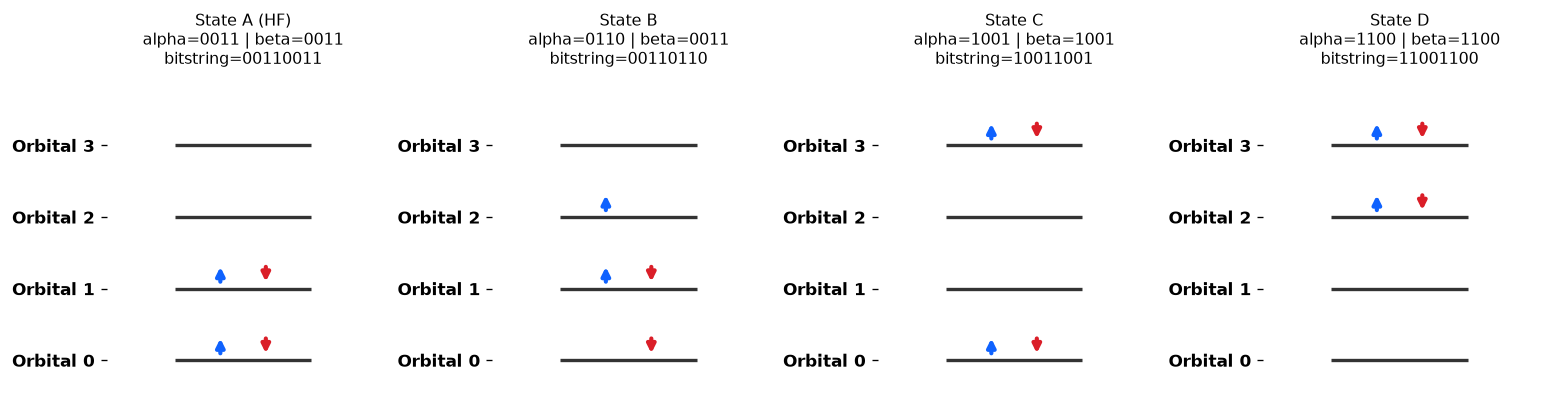

In [3]:
# Code Cell 2.2: Exercise 2 Solutions
# ================== EXERCISE 2 ==================
# 1. State A: Hartree-Fock ground state
alpha_A = "0011"
beta_A  = "0011"
bitstring_A = beta_A + alpha_A

# 2. State B: Single excitation
alpha_B = "0110"
beta_B  = "0011"
bitstring_B = beta_B + alpha_B

# 3. State C: Double excitation
alpha_C = "1001"
beta_C  = "1001"
bitstring_C = beta_C + alpha_C

# 4. State D: Quadruple excitation
alpha_D = "1100"
beta_D  = "1100"
bitstring_D = beta_D + alpha_D

print(f"State A: {bitstring_A}")
print(f"State B: {bitstring_B}")
print(f"State C: {bitstring_C}")
print(f"State D: {bitstring_D}")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
draw_molecular_configuration(alpha_A, beta_A, axes[0], "State A (HF)")
draw_molecular_configuration(alpha_B, beta_B, axes[1], "State B")
draw_molecular_configuration(alpha_C, beta_C, axes[2], "State C")
draw_molecular_configuration(alpha_D, beta_D, axes[3], "State D")
plt.tight_layout()
plt.show()

### ✏️ Exercise 3: Determinant Counting & Combinatorics ($H_4$)

In classical computing, one might worry that with $N$ qubits, there are $2^N$ possible configurations to consider.
For an 8-qubit system representing 4 spatial orbitals in minimal basis $H_4$, how many total bitstrings exist, and how many are physically valid?

In this exercise:
1. You will compute the number of **total bitstrings** ($2^{2M}$) and the number of bitstrings that satisfy **particle number and spin conservation** $\binom{M}{N_\alpha} \times \binom{M}{N_\beta}$ for 4 electrons in 4 orbitals ($N_\alpha = 2, N_\beta = 2$).
2. We then evaluate the exact Full Configuration Interaction (FCI) wavefunction of $H_4$ in the STO-3G minimal basis (4 orbitals = 8 qubits) and plot the probability distribution across all determinants.

*(Solutions are provided in Part 9.)*

---

> [!TIP]
> ### 🤔 Predict Before Running:
> * **Prediction Prompt**: Out of the $2^8 = 256$ possible bitstrings, how many do you predict satisfy both particle count ($N_e=4$) and zero net spin ($N_\alpha = N_\beta = 2$)? In an equilibrium molecule, do you expect the probability to spread evenly across all valid states or concentrate sharply in a tiny handful?
> * **What would challenge your hypothesis?** If the bar chart revealed dozens of determinants with similar 2%–5% probabilities and no dominant state, a small 4-determinant subspace would fail to approximate the true energy. Watch the output to see if probability concentration holds!


In [4]:
# Code Cell 2.3: Determinant Counting & Wavefunction Concentration
# ================== EXERCISE 3 ==================
norb = 4                # 4 spatial orbitals -> 8 qubits
n_alpha, n_beta = 2, 2  # H4 minimal basis has 2 alpha electrons and 2 beta electrons

# 1. Total mathematically possible bitstrings on 8 qubits (2 * norb)
total_possible_bitstrings = 2**(2*norb)

# 2. Number of bitstrings that strictly conserve particle number (Ne = 4) and spin (Sz = 0)
spin_conserving_bitstrings = math.comb(norb, n_alpha)*math.comb(norb, n_beta)

print("=== Determinant Counting Analysis (4 Orbitals = 8 Qubits) ===")
print(f"Total mathematically possible bitstrings: {total_possible_bitstrings}")
print(f"Configurations conserving Ne=4 and Sz=0:  {spin_conserving_bitstrings}")

=== Determinant Counting Analysis (4 Orbitals = 8 Qubits) ===
Total mathematically possible bitstrings: 256
Configurations conserving Ne=4 and Sz=0:  36


**The combinatorics:** choose two of four alpha seats (6 choices), independently choose two beta seats (6 choices). Multiply: $6	imes6=36$. The 256 count ignores this physical constraint.

Exercise 4: 4 determinants exceed 0.5%; 256 total strings, 36 physical strings.
Hartree–Fock determinant weight at R=1.0 Å: 93.65%


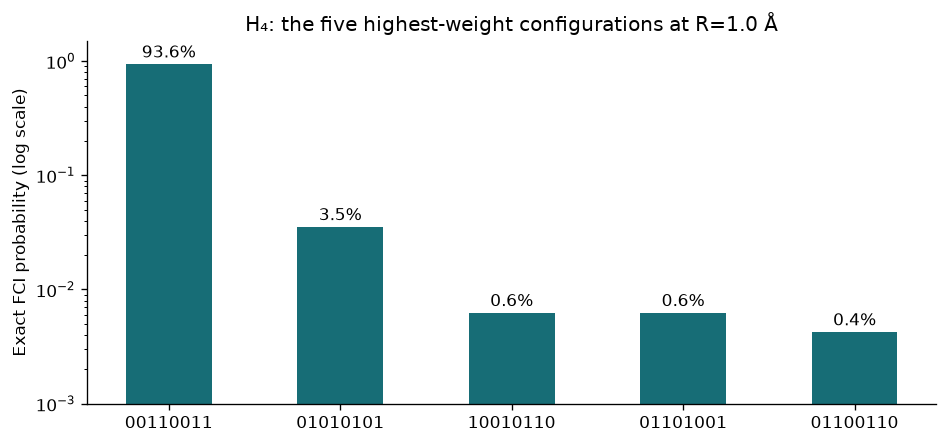

In [5]:
# Exact FCI is used only for evaluation/teaching, never for circuit preparation.
mol_h4 = gto.M(atom='H 0 0 0; H 0 0 1; H 0 0 2; H 0 0 3', basis='sto-3g', verbose=0)
mf_h4 = scf.RHF(mol_h4).run()
assert mf_h4.converged
cisolver = fci.FCI(mf_h4)
e_fci_h4, civec_h4 = cisolver.kernel()

# PySCF orders strings by integer occupation pattern, not itertools.combinations.
alpha_strings = fci.cistring.make_strings(range(norb), n_alpha)
beta_strings = fci.cistring.make_strings(range(norb), n_beta)
det_probs = {}
for a_idx, alpha in enumerate(alpha_strings):
    for b_idx, beta in enumerate(beta_strings):
        packed = f'{int(beta):0{norb}b}{int(alpha):0{norb}b}'
        det_probs[packed] = float(abs(civec_h4[a_idx, b_idx])**2)
assert np.isclose(sum(det_probs.values()), 1)
assert len(det_probs) == spin_conserving_bitstrings
sorted_dets = sorted(det_probs.items(), key=lambda item: item[1], reverse=True)
h4_configs = [det for det, probability in sorted_dets[:5]]
h4_probabilities = [probability for det, probability in sorted_dets[:5]]
hf_weight = 100 * det_probs['00110011']
substantial_determinants = sum(p > .005 for p in det_probs.values())
print(f'Exercise 4: {substantial_determinants} determinants exceed 0.5%; 256 total strings, 36 physical strings.')
print(f'Hartree–Fock determinant weight at R=1.0 Å: {hf_weight:.2f}%')
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(h4_configs, h4_probabilities, color='#176d76', width=.5)
ax.set_yscale('log'); ax.set_ylim(1e-3, 1.5)
ax.set_ylabel('Exact FCI probability (log scale)')
ax.set_title('H₄: the five highest-weight configurations at R=1.0 Å')
for bar, probability in zip(bars, h4_probabilities):
    ax.text(bar.get_x()+bar.get_width()/2, probability*1.15, f'{probability:.1%}', ha='center')
plt.tight_layout(); plt.show()


### Exercise 4 — interpret the measured answer
The preceding cell prints the number of determinants above 0.5% **for this geometry and basis**. It also prints the computed Hartree–Fock weight. There are 256 mathematical strings, but only 36 have the required spin-resolved electron counts.

Concentrated probability suggests a useful small basis; it does not prove a small basis gives an accurate energy. Couplings to omitted configurations can matter. Exact FCI probabilities are an educational reference, not input to our sampler.


## ⚙️ Part 3: SQD Under the Hood: Algorithmic Implementation

Let's build the core stages of the SQD algorithm step by step using Python.

### The 4 Core Stages:
1. **Physical Symmetry Filter**: Check each measured bitstring against particle number ($N_e$) and spin projection ($S_z$), filtering out unphysical bitstrings.
2. **Excitation Rank & Slater-Condon Coupling**: Determine how many electrons differ between determinants and compute their Hamiltonian matrix elements.
3. **Subspace Hamiltonian Projection**: Assemble the $d \times d$ matrix $H_S = \langle D_k | H | D_l \rangle$.
4. **Rayleigh-Ritz Subspace Eigensolver**: Classical diagonalization to find the Ritz ground state energy.


### ✏️ Exercise 5: Building the Physical Symmetry Filter

A key classical advantage of SQD is that physical conservation laws ($N_e$ and $S_z$) can be checked directly on measured bitstrings. Any shot corrupted by hardware bit-flip errors that alters particle count or spin can be identified immediately.

In this exercise, you will complete the function `filter_physical_configurations`:
1. Use `unpack_bitstring` to split each measured bitstring into `alpha` and `beta` substrings.
2. Count the number of electrons (number of `'1'`s) in both registers.
3. Keep only the bitstrings where `(n_a, n_b) == target_nelec`.
4. Return a list of unique valid bitstrings.

*(Solutions are provided in Part 9.)*

---

> [!TIP]
> ### 🤔 Predict Before Running:
> * **Prediction Prompt**: If hardware noise causes a single bit-flip error ($0 \to 1$ or $1 \to 0$), will the corrupted string ever pass this filter? What about a double bit flip?
> * **What would challenge your hypothesis?** If a double bit flip simultaneously created an electron ($0 \to 1$) in one orbital and destroyed an electron ($1 \to 0$) in another within the same spin sector, could the symmetry filter distinguish that error from a legitimate physical excitation? Keep this question in mind as we evaluate noise in Part 4!


In [6]:
# Code Cell 3.1: Physical Symmetry Filter
def unpack_bitstring(bs: str, norb: int):
    """Split packed bitstring (beta + alpha) into (alpha_str, beta_str)."""
    assert len(bs) == 2 * norb, f"Expected bitstring of length {2*norb}, got {len(bs)}"
    beta = bs[:norb]
    alpha = bs[norb:]
    return alpha, beta

# ================== EXERCISE 5 ==================
def filter_physical_configurations(bitstrings: list[str], norb: int, target_nelec: tuple[int, int]) -> list[str]:
    """
    Sift sampled bitstrings: keep only those with valid alpha and beta electron counts.

    Parameters:
        bitstrings: List of raw measured bitstrings from quantum sampler
        norb: Number of spatial orbitals
        target_nelec: Tuple of (target_alpha_electrons, target_beta_electrons)

    Returns:
        A single list of unique valid bitstrings preserving order of appearance.
    """
    target_alpha, target_beta = target_nelec
    valid_list = []

    for bs in bitstrings:
        alpha, beta = unpack_bitstring(bs, norb)
        n_a = alpha.count('1')
        n_b = beta.count('1')

        # 2. Append bs if electron counts match target_alpha and target_beta
        if n_a == target_alpha and n_b == target_beta:
            valid_list.append(bs)

    # Return unique valid determinants preserving order of appearance
    unique_valid = list(dict.fromkeys(valid_list))
    return unique_valid

# =============================================================
target_norb = 4               # 4 spatial orbitals (8 qubits)
target_nelec = (2, 2)          # (2 alpha electrons, 2 beta electrons)

mock_samples = [
    "00110011",  # Valid (Hartree-Fock state)
    "00110011",  # Duplicate valid
    "01010101",  # Valid (Double excitation)
    "00100011",  # Invalid (Missing beta electron!)
    "01110011",  # Invalid (Too many beta electrons!)
]

valid_dets = filter_physical_configurations(mock_samples, norb=target_norb, target_nelec=target_nelec)

total_samples = len(mock_samples)
retained_samples = sum(1 for bs in mock_samples if bs in valid_dets)
invalid_samples = total_samples - retained_samples
valid_fraction = retained_samples / total_samples if total_samples > 0 else 0.0

print("=== Symmetry Filtering Audit (H4 Minimal Basis) ===")
print(f"Total samples:                 {total_samples}")
print(f"Valid samples accepted:        {retained_samples}")
print(f"Invalid samples rejected:      {invalid_samples}")
print(f"Retention rate:                {valid_fraction * 100:.1f}%")
print(f"Unique physical determinants:  {len(valid_dets)}")
print(f"Retained bitstrings:           {valid_dets}")
assert valid_dets == ['00110011', '01010101']
assert retained_samples == 3 and invalid_samples == 2


=== Symmetry Filtering Audit (H4 Minimal Basis) ===
Total samples:                 5
Valid samples accepted:        3
Invalid samples rejected:      2
Retention rate:                60.0%
Unique physical determinants:  2
Retained bitstrings:           ['00110011', '01010101']


**Shots versus configurations:** our five toy shots include three accepted shots but just two distinct accepted determinants. Repetition increases frequency, not the size of the selected matrix.

### The Slater-Condon Selection Rules & Excitation Rank

When two Slater determinants $|D_k\rangle$ and $|D_l\rangle$ are compared, their **excitation rank** is the number of electrons that must change orbitals to transform $D_k$ into $D_l$:
* **Rank 0 (Diagonal)**: $D_k = D_l$. The energy is the sum of 1-electron energies plus Coulomb and exchange interactions.
* **Rank 1 (Single Excitation)**: Exactly 1 electron moved ($p \to q$). Coupled by 1-body integrals and 2-body Coulomb/exchange fields.
* **Rank 2 (Double Excitation)**: Exactly 2 electrons moved ($p, r \to q, s$). Coupled directly by the 2-electron Coulomb repulsion $(pq|rs)$.
* **Rank $\ge 3$ (Triple or higher)**: **Zero coupling!** Because physical electromagnetic interactions involve at most two electrons at a time, the Hamiltonian contains only 1- and 2-body operators. Determinants differing by 3 or more electrons have zero direct Hamiltonian coupling!

<details>
<summary>🔎 <b>Optional Deep-Dive: Mathematical Formulation of Slater-Condon Rules</b></summary>

For a non-relativistic electronic Hamiltonian:
$$\hat{H} = E_{\text{nuc}} + \sum_{pq} h_{pq} \hat{a}_p^\dagger \hat{a}_q + \frac{1}{2} \sum_{pqrs} g_{pqrs} \hat{a}_p^\dagger \hat{a}_q^\dagger \hat{a}_s \hat{a}_r$$

The matrix elements between orthonormal determinants $|D_k\rangle$ and $|D_l\rangle$ follow from Wick's theorem:
1. **Rank 0 (Diagonal)**:
   $$\langle D_k | H | D_k \rangle = E_{\text{nuc}} + \sum_{p \in D_k} h_{pp} + \sum_{p < q \in D_k} \left[ (pp|qq) - \delta_{\sigma_p, \sigma_q}(pq|qp) \right]$$
2. **Rank 1 (Single Excitation $p \in D_k \to q \in D_l$)**:
   $$\langle D_k | H | D_l \rangle = \pm \left( h_{pq} + \sum_{r \in D_k \cap D_l} \left[ (pq|rr) - \delta_{\sigma_p, \sigma_r}(pr|rq) \right] \right)$$
3. **Rank 2 (Double Excitation $p, r \in D_k \to q, s \in D_l$)**:
   $$\langle D_k | H | D_l \rangle = \pm \left[ \delta_{\sigma_p, \sigma_q} \delta_{\sigma_r, \sigma_s} (pq|rs) - \delta_{\sigma_p, \sigma_s} \delta_{\sigma_r, \sigma_q} (ps|rq) \right]$$
4. **Rank $\ge 3$**:
   $$\langle D_k | H | D_l \rangle = 0$$

The phase factors $(\pm)$ arise from the anti-commutation of fermionic creation/annihilation operators when bringing the determinants to maximum coincidence.
</details>

---

### ✏️ Exercise 6: Excitation Rank & Selection Rule Check
**Question**: *Determinant $A$ is `00110011` (Hartree-Fock state of $H_4$) and Determinant $B$ is `11001100` (quadruple excitation where all 4 electrons occupy orbitals 2 and 3). What is their excitation rank? What is the Hamiltonian coupling $\langle A | H | B \rangle$?*

*(Solutions are provided in Part 9.)*

---

> [!TIP]
> ### 🤔 Predict Before Running:
> * **Prediction Prompt**: In Cell 3.2, you will compute the excitation rank. What is the Hamming distance between two determinants that differ by a single excitation? What is the excitation rank?
> * **What would challenge your hypothesis?** If two determinants differ in total Hamming weight (different number of 1s), does excitation rank have meaning? (Recall: physical determinants must conserve particle count!)


### ✏️ Exercise 7: Computing Excitation Rank

To build the subspace Hamiltonian $H_S$, we need to evaluate the coupling between every pair of determinants. Because determinants are represented as bitstrings, the number of orbitals that differ between two valid determinants of equal electron count is twice the number of excitations (one bit changes from `1` to `0`, and another changes from `0` to `1`).

In this exercise, you will complete the function `compute_excitation_rank`:
* Compare the characters in `det1` and `det2`.
* Calculate the number of differing positions (Hamming distance) and divide by 2.

*(Solutions are provided in Part 9.)*


In [7]:
# Exercise 7: valid determinants differ by one removed/added electron per excitation.
def compute_excitation_rank(det1: str, det2: str) -> int:
    if len(det1) != len(det2) or any(bit not in '01' for bit in det1+det2):
        raise ValueError('Use equal-length binary strings')
    if det1.count('1') != det2.count('1'):
        raise ValueError('Excitation rank here requires equal electron number')
    return sum(a != b for a,b in zip(det1, det2)) // 2

assert compute_excitation_rank('00110011', '11001100') == 4
print('Exercise 6: rank 4. A one-/two-body electronic Hamiltonian cannot connect these directly.')


Exercise 6: rank 4. A one-/two-body electronic Hamiltonian cannot connect these directly.


In [8]:
# Code Cell 3.3: Advanced Implementation - Slater-Condon Subspace Projection (Not required for Exercise 7)
def get_occupied_spin_orbitals(det_str: str, norb: int) -> list[int]:
    occ = []
    for p in range(norb):
        if det_str[2 * norb - 1 - p] == '1':
            occ.append(p)
    for p in range(norb):
        if det_str[norb - 1 - p] == '1':
            occ.append(norb + p)
    return sorted(occ)

def slater_condon_matrix_element(det_k: str, det_l: str, h_mo: np.ndarray, eri_mo: np.ndarray, e_nuc: float) -> float:
    norb = h_mo.shape[0]
    occ_k = get_occupied_spin_orbitals(det_k, norb)
    occ_l = get_occupied_spin_orbitals(det_l, norb)

    set_k, set_l = set(occ_k), set(occ_l)
    diff_k = sorted(list(set_k - set_l))
    diff_l = sorted(list(set_l - set_k))
    rank = len(diff_k)

    if rank > 2:
        return 0.0

    def sp(p): return p % norb
    def spin(p): return 0 if p < norb else 1

    if rank == 0:
        val = e_nuc
        for p in occ_k:
            val += h_mo[sp(p), sp(p)]
        for i_idx, p in enumerate(occ_k):
            for q in occ_k[i_idx + 1:]:
                val += eri_mo[sp(p), sp(p), sp(q), sp(q)]
                if spin(p) == spin(q):
                    val -= eri_mo[sp(p), sp(q), sp(q), sp(p)]
        return val

    def perm_phase(p, q, ok, ol):
        return (-1) ** (ok.index(p) + ol.index(q))

    if rank == 1:
        p, q = diff_k[0], diff_l[0]
        if spin(p) != spin(q):
            return 0.0
        phase = perm_phase(p, q, occ_k, occ_l)
        val = h_mo[sp(p), sp(q)]
        for r in (set_k & set_l):
            val += eri_mo[sp(p), sp(q), sp(r), sp(r)]
            if spin(p) == spin(r):
                val -= eri_mo[sp(p), sp(r), sp(r), sp(q)]
        return phase * val

    if rank == 2:
        p, r = diff_k[0], diff_k[1]
        q, s = diff_l[0], diff_l[1]
        val = 0.0
        if spin(p) == spin(q) and spin(r) == spin(s):
            val += eri_mo[sp(p), sp(q), sp(r), sp(s)]
        if spin(p) == spin(s) and spin(r) == spin(q):
            val -= eri_mo[sp(p), sp(s), sp(r), sp(q)]
        pos_sum = occ_k.index(p) + occ_k.index(r) + occ_l.index(q) + occ_l.index(s)
        return ((-1) ** pos_sum) * val

def project_subspace_hamiltonian(determinants: list[str], h_mo: np.ndarray, eri_mo: np.ndarray, e_nuc: float) -> np.ndarray:
    d = len(determinants)
    H_S = np.zeros((d, d))
    for i in range(d):
        for j in range(i, d):
            val = slater_condon_matrix_element(determinants[i], determinants[j], h_mo, eri_mo, e_nuc)
            H_S[i, j] = val
            H_S[j, i] = val
    return H_S

def get_h2_integrals(bond_distance_ang=0.7414):
    mol = gto.M(atom=f"H 0 0 0; H 0 0 {bond_distance_ang}", basis="sto-3g", verbose=0)
    mf = scf.RHF(mol).run()
    h_core = mf.get_hcore()
    h_mo = mf.mo_coeff.T @ h_core @ mf.mo_coeff
    eri_mo = ao2mo.restore(1, ao2mo.kernel(mol, mf.mo_coeff), mol.nao)
    e_nuc = mol.energy_nuc()
    e_hf = mf.e_tot
    return h_mo, eri_mo, e_nuc, e_hf

h_mo_h2, eri_mo_h2, e_nuc_h2, e_hf_h2 = get_h2_integrals(0.7414)

def build_h2_circuit(theta: float = 0.35, measure: bool = True):
    qc = QuantumCircuit(4)
    qc.x(0)
    qc.x(2)
    qc.append(XXPlusYYGate(2 * theta), [0, 1])
    qc.append(XXPlusYYGate(2 * theta), [2, 3])
    if measure:
        qc.measure_all()
    return qc

def validate_projection(determinants, hcore, eri, offset, exact_reference=None):
    handmade = project_subspace_hamiltonian(determinants, hcore, eri, offset)
    mapped = JordanWignerMapper().map(ElectronicEnergy.from_raw_integrals(hcore, eri).second_q_op()).to_matrix()
    indices = [int(det, 2) for det in determinants]
    reference = mapped[np.ix_(indices, indices)] + offset*np.eye(len(indices))
    np.testing.assert_allclose(handmade, reference, atol=1e-10)
    np.testing.assert_allclose(handmade, handmade.T, atol=1e-10)
    if exact_reference is not None:
        assert abs(np.linalg.eigvalsh(handmade)[0]-exact_reference) < 1e-8
    return handmade

h2_molecule = gto.M(atom='H 0 0 0; H 0 0 .7414', basis='sto-3g', verbose=0)
h2_hf = scf.RHF(h2_molecule).run()
independent_fci_h2, _ = fci.FCI(h2_hf).kernel()
validate_projection(['0101','1010','0110','1001'], h_mo_h2, eri_mo_h2, e_nuc_h2, independent_fci_h2)
print('H2 handwritten matrix matches Qiskit Nature and independent PySCF FCI.')


H2 handwritten matrix matches Qiskit Nature and independent PySCF FCI.


**The Hamiltonian is the rulebook:** diagonal entries are energies of individual arrangements; off-diagonal entries connect arrangements. The eigenvector chooses how to combine them. The independent dense check below is affordable here, not at large molecular sizes.

In [9]:
# Code Cell 3.4: Head-to-Head: Unoptimized Ansatz Expectation Value vs. Subspace Energy
fci_dets = ["0101", "1010", "0110", "1001"]
H_full = project_subspace_hamiltonian(fci_dets, h_mo_h2, eri_mo_h2, e_nuc_h2)
e_fci_h2 = float(scipy.linalg.eigh(H_full)[0][0])

theta_approx = 0.350
qc_h2_measure = build_h2_circuit(theta=theta_approx, measure=True)

backend = AerSimulator()
qc_h2_t = transpile(qc_h2_measure, backend)
shots = 10_000
raw_counts = backend.run(qc_h2_t, shots=shots, seed_simulator=42).result().get_counts()

sampled_dets = sorted(list(raw_counts.keys()))
print(f"Sampled basis determinants from quantum circuit: {sampled_dets}")
print(f"Sampled measurement counts: {raw_counts}")

qc_h2_state = build_h2_circuit(theta=theta_approx, measure=False)
sv = Statevector.from_instruction(qc_h2_state)
amp_dict = sv.to_dict()
psi_ansatz = np.array([amp_dict.get(d, 0.0) for d in fci_dets])
e_ansatz = float(np.real(psi_ansatz.conj() @ H_full @ psi_ansatz))

H_sqd = project_subspace_hamiltonian(sampled_dets, h_mo_h2, eri_mo_h2, e_nuc_h2)
evals_sqd, evecs_sqd = scipy.linalg.eigh(H_sqd)
e_sqd_h2 = float(evals_sqd[0])
c_sqd = evecs_sqd[:, 0]

print("\n=== The Unoptimized Quantum State Head-to-Head ===")
print(f"Exact FCI Benchmark:                   {e_fci_h2:.6f} Ha")
print(f"Unoptimized Ansatz Expectation Value:  {e_ansatz:.6f} Ha  (Error: {(e_ansatz - e_fci_h2)*1000:+7.2f} mHa)")
print(f"SQD Subspace Diagonalization Energy:   {e_sqd_h2:.6f} Ha  (Error: {(e_sqd_h2 - e_fci_h2)*1000:+7.2f} mHa)")
print("\n*Note: SQD matches FCI perfectly here because the sampled list of 4 determinants contains the entire spin-conserving sector of H2.*")
assert sum(raw_counts.values()) == shots
assert e_sqd_h2 >= independent_fci_h2-1e-8
assert np.isclose(np.vdot(psi_ansatz, psi_ansatz), 1)


Sampled basis determinants from quantum circuit: ['0101', '0110', '1001', '1010']
Sampled measurement counts: {'1010': 142, '1001': 1016, '0110': 1037, '0101': 7805}

=== The Unoptimized Quantum State Head-to-Head ===
Exact FCI Benchmark:                   -1.137270 Ha
Unoptimized Ansatz Expectation Value:  -0.936051 Ha  (Error: +201.22 mHa)
SQD Subspace Diagonalization Energy:   -1.137270 Ha  (Error:   +0.00 mHa)

*Note: SQD matches FCI perfectly here because the sampled list of 4 determinants contains the entire spin-conserving sector of H2.*


**What changed?** The measured circuit state was not optimized. SQD changes the coefficients after sampling. H2 is exact here because all four allowed configurations were sampled; uniform classical samples can do this too.

## Part 4: Ideal samples and synthetic readout noise
The following example samples the same H2 circuit, then independently flips each **measured bit** with probability 0.04. This models synthetic readout corruption; it is not a real hardware experiment or a calibrated gate-noise simulation.

A single flip changes an electron count and fails the symmetry filter. Multiple flips can preserve counts and pass. Therefore the accepted fraction is not exactly the probability of zero flips, `(1-p)^n`.

Filtering removes unphysical configurations, but surviving errors can still change which physical configurations are discovered. A variational bound is not a guarantee of accurate energy.


### ✏️ Exercise 8: Quantifying Noise Shot Rejection

Under physical hardware noise, many bitstrings violate symmetry constraints and are rejected by post-selection filtering.

In this exercise, you will quantify the cost of post-selection filtering under a 4% bit-flip noise rate on $H_2$ (4 qubits):
1. Calculate the fraction of shots that survived filtering (`noisy_valid_fraction`).
2. Calculate the exact number of corrupted shots discarded (`noisy_invalid_count`).

*(Solutions are provided in Part 9.)*

---

> [!TIP]
> ### 🤔 Predict Before Running:
> * **Prediction Prompt**: If each of the 4 qubits has an independent 4% chance of flipping ($p=0.04$), what is the probability that a shot suffers **zero bit flips**?
> * **What would challenge your hypothesis?** Do you expect the surviving valid fraction to match $(1 - p)^4$ exactly? (Hint: Could two bit flips cancel each other out in total count?) Check the output of Cell 4.1 to compare!


In [10]:
# Code Cell 4.1: Noisy vs. Noisy 3-Condition Experiment
norb_h2 = 2
qc_clean = build_h2_circuit(theta=0.35, measure=True)

backend = AerSimulator()
qc_clean_t = transpile(qc_clean, backend)
shots = 100
clean_counts = backend.run(qc_clean_t, shots=shots, seed_simulator=42).result().get_counts()

def add_bit_flip_noise(counts_dict: dict, p_flip: float = 0.04, seed: int = 123):
    rng = np.random.default_rng(seed)
    noisy_counts = {}
    for bs, cnt in counts_dict.items():
        bits = np.array([int(b) for b in bs])
        for _ in range(cnt):
            flips = rng.random(len(bits)) < p_flip
            noisy_bs = "".join(str(b) for b in (bits ^ flips))
            noisy_counts[noisy_bs] = noisy_counts.get(noisy_bs, 0) + 1
    return noisy_counts

noisy_counts = add_bit_flip_noise(clean_counts, p_flip=0.04)

clean_stream = [bs for bs, c in clean_counts.items() for _ in range(c)]
noisy_stream = [bs for bs, c in noisy_counts.items() for _ in range(c)]

clean_valid = filter_physical_configurations(clean_stream, norb=2, target_nelec=(1, 1))
noisy_valid = filter_physical_configurations(noisy_stream, norb=2, target_nelec=(1, 1))


# ================== EXERCISE 8 ==================
clean_retained_count = sum(clean_counts.get(bs, 0) for bs in clean_valid)
noisy_retained_count = sum(noisy_counts.get(bs, 0) for bs in noisy_valid)

# Compute the valid fraction of shots (retained shots / total shots)
noisy_valid_fraction = noisy_retained_count / len(noisy_stream)

# Compute the number of rejected corrupted shots (total shots - retained shots)
noisy_invalid_count = len(noisy_stream) - noisy_retained_count

e_clean_sqd = float(np.linalg.eigvalsh(project_subspace_hamiltonian(clean_valid, h_mo_h2, eri_mo_h2, e_nuc_h2))[0])
e_noisy_sqd = float(np.linalg.eigvalsh(project_subspace_hamiltonian(noisy_valid, h_mo_h2, eri_mo_h2, e_nuc_h2))[0])

clean_sv = Statevector.from_instruction(build_h2_circuit(theta=.35, measure=False))
clean_psi = np.array([clean_sv.data[int(det, 2)] for det in fci_dets])
e_clean_ansatz = float(np.real(clean_psi.conj() @ H_full @ clean_psi))

print("=== Local simulation: three-condition comparison ===")
print(f"Condition 1 (Clean Ansatz Expectation): Error = {(e_clean_ansatz - e_fci_h2)*1000:+7.2f} mHa")
print(f"Condition 2 (Clean SQD Subspace):        Error = {(e_clean_sqd - e_fci_h2)*1000:+7.2f} mHa")
print(f"Condition 3 (Noisy SQD Subspace):        Error = {(e_noisy_sqd - e_fci_h2)*1000:+7.2f} mHa")
print(f"\nValid Sample Fraction under 4% Noise:  {noisy_valid_fraction*100:.1f}%")
print(f"Invalid Corrupted Shots Rejected:       {noisy_invalid_count:,} shots")
assert clean_retained_count == shots
assert noisy_retained_count + noisy_invalid_count == shots
assert 0 <= noisy_valid_fraction <= 1


=== Local simulation: three-condition comparison ===
Condition 1 (Clean Ansatz Expectation): Error = +201.22 mHa
Condition 2 (Clean SQD Subspace):        Error =   +0.00 mHa
Condition 3 (Noisy SQD Subspace):        Error =   +0.00 mHa

Valid Sample Fraction under 4% Noise:  87.0%
Invalid Corrupted Shots Rejected:       13 shots


---

### ✏️ Exercise 9: Quick Noise Symmetry Check ($H_4$)
**Question**: *A quantum computer measuring the 8-qubit $H_4$ state ($N_\alpha = 2, N_\beta = 2$) outputs the bitstring `00110001`. How many electrons are in $\alpha$ and $\beta$? Does this bitstring pass the symmetry filter?*

*(Solutions are provided in Part 9.)*


## Part 5: Recovery repairs counts, not the lost information
Postselection throws away invalid samples. Occupation-guided recovery instead changes invalid strings into strings with the required alpha and beta electron counts, using estimates of average orbital occupation.

The recovered distribution can retain the original probability mass. That **does not mean** it recovers each original determinant or recreates the pre-noise distribution. It is a heuristic proposal of physically allowed configurations. Several strings can merge into one recovered string.

For independent bit flips, `(1-p)^n` is the probability of zero flips. The particle-count acceptance probability can be higher because balanced flips also pass. Neither quantity directly guarantees useful determinant coverage or an accurate energy.

The next cell uses explicitly assumed illustrative occupancies, not an experimentally measured one-particle density matrix.


### ✏️ Exercise 10: Active Configuration Recovery with Qiskit Addon

In this exercise, you will apply the official configuration recovery engine from `qiskit_addon_sqd.configuration_recovery` to a hand-constructed batch of noisy 8-qubit occupation strings ($N_\alpha = 2, N_\beta = 2$ in 4 orbitals).

In the code cell below:
1. Review the input noisy bitstrings: several strings have incorrect electron counts (such as 3 electrons or 5 electrons due to bit-flip noise).
2. Call `recover_configurations` with `bitstring_matrix`, `noisy_probs`, `avg_occupancies`, `num_elec_a=2`, and `num_elec_b=2`.
3. Verify that 100% of the recovered configurations strictly conserve $N_\alpha = 2$ and $N_\beta = 2$ while conserving total probability mass.

*(Solutions are provided in Part 9.)*

---

> [!TIP]
> ### 🤔 Predict Before Running:
> * **Prediction Prompt**: The corrupted bitstring `00110001` has only 1 $\alpha$ electron (orbital 0 is occupied). Target is 2 $\alpha$ electrons. The occupancies for $\alpha$ are $\langle n \rangle = [0.95, 0.90, 0.10, 0.05]$. Which orbital do you predict `recover_configurations` will most likely populate with the missing electron?
> * **What would challenge your hypothesis?** If the recovered configuration had its second electron placed into orbital 3 (occupancy only 0.05), that would be a rare stochastic outcome, not a contradiction. Recovery favors likely occupations but is not deterministic. Check the output of Cell 5.1!


In [11]:
# Code Cell 5.1: Active Configuration Recovery Demonstration
from qiskit_addon_sqd.configuration_recovery import recover_configurations

# 1. Hand-constructed toy input for eight qubits (four orbitals, two alpha/two beta)
# Notice: some bitstrings are corrupted by bit-flip errors!
raw_noisy_strings = [
    "00110011",  # Physical (Hartree-Fock state, 4 electrons)
    "01010011",  # Physical (Single excitation, 4 electrons)
    "00110001",  # UNPHYSICAL (Corrupted: only 1 alpha electron, total 3 electrons)
    "01110011",  # UNPHYSICAL (Corrupted: 3 beta electrons, total 5 electrons)
    "00100011",  # UNPHYSICAL (Corrupted: only 1 beta electron, total 3 electrons)
    "01010101",  # Physical (Double excitation, 4 electrons)
]
noisy_probs = np.array([0.45, 0.20, 0.12, 0.10, 0.08, 0.05])
noisy_probs = noisy_probs / np.sum(noisy_probs)

# Convert string representation to 2D boolean matrix (n_samples x n_qubits)
bitstring_matrix = np.array([[b == "1" for b in bs] for bs in raw_noisy_strings])

# 2. Illustrative occupancies for this recovery exercise, not measured H4 data
occ_alpha = np.array([0.95, 0.90, 0.10, 0.05])
occ_beta  = np.array([0.95, 0.90, 0.10, 0.05])
avg_occupancies = (occ_alpha, occ_beta)

print("=== Raw Noisy Samples Audit ===")
for bs, p in zip(raw_noisy_strings, noisy_probs):
    na, nb = bs[4:].count("1"), bs[:4].count("1")
    valid_str = "\u2705 Valid" if (na == 2 and nb == 2) else f"\u274c Corrupted (\u03b1={na}, \u03b2={nb})"
    print(f"  Bitstring: {bs} | Prob: {p*100:5.1f}% | {valid_str}")

# ================== EXERCISE 10 ==================
# Refine the corrupted bitstrings using active configuration recovery
# Target electron counts: num_elec_a = 2, num_elec_b = 2
recovered_result = recover_configurations(
    bitstring_matrix, noisy_probs, avg_occupancies,
    num_elec_a=2, num_elec_b=2, rand_seed=42,
)

# =============================================================
if recovered_result is not None:
    recovered_matrix, recovered_probs = recovered_result
    recovered_strings = ["".join("1" if b else "0" for b in row) for row in recovered_matrix]

    print("\n=== Recovered Physical Configurations ===")
    all_physical = True
    for bs, p in zip(recovered_strings, recovered_probs):
        na, nb = bs[4:].count("1"), bs[:4].count("1")
        is_phys = (na == 2 and nb == 2)
        all_physical = all_physical and is_phys
        status = "\u2705 Valid Physical Determinant" if is_phys else "\u274c Still Corrupted"
        print(f"  Recovered: {bs} | Weight: {p*100:5.1f}% | {status}")

    print(f"\nAll configurations recovered into physical manifold: {all_physical}")
    print(f"Total probability mass conserved: {np.sum(recovered_probs):.4f} (normalized weight retained; original configurations not guaranteed)")
else:
    print("\nComplete Exercise 10 above to run configuration recovery!")
assert all_physical
assert np.isclose(np.sum(recovered_probs), 1)


=== Raw Noisy Samples Audit ===
  Bitstring: 00110011 | Prob:  45.0% | ✅ Valid
  Bitstring: 01010011 | Prob:  20.0% | ✅ Valid
  Bitstring: 00110001 | Prob:  12.0% | ❌ Corrupted (α=1, β=2)
  Bitstring: 01110011 | Prob:  10.0% | ❌ Corrupted (α=2, β=3)
  Bitstring: 00100011 | Prob:   8.0% | ❌ Corrupted (α=2, β=1)
  Bitstring: 01010101 | Prob:   5.0% | ✅ Valid

=== Recovered Physical Configurations ===
  Recovered: 00110011 | Weight:  75.0% | ✅ Valid Physical Determinant
  Recovered: 01010011 | Weight:  20.0% | ✅ Valid Physical Determinant
  Recovered: 01010101 | Weight:   5.0% | ✅ Valid Physical Determinant

All configurations recovered into physical manifold: True
Total probability mass conserved: 1.0000 (normalized weight retained; original configurations not guaranteed)


**Recovery is not a time machine:** the returned strings have valid electron counts, but may differ from their true pre-noise values. Keeping normalized probability weight is not the same as keeping all original information.

## Part 6: An end-to-end H4 calculation
PySCF supplies integrals and converged CCSD amplitudes. `ffsim` turns those amplitudes into a unitary cluster-Jastrow (UCJ) circuit. Qiskit Aer supplies finite-shot samples, then the official SQD solver selects, recovers and diagonalizes configurations.

**Two distinct jobs:** CCSD helps prepare the sampling circuit; FCI is used only to evaluate its result. Count CCSD's classical preparation cost when comparing methods. This is UCJ, not a hardware-connectivity-constrained LUCJ experiment.

`amplitude_scale` actually scales the CCSD amplitudes passed to the circuit builder. A scale of zero returns the HF preparation; one uses the full CCSD-informed initialization. These values are explicit design choices, not optimized parameters.

The full 36-determinant H4 matrix is checked here because this is a tiny teaching example. That dense check is not a scalable implementation.


In [12]:
@lru_cache(maxsize=16)
def build_active_space_problem(atom=None, basis='sto-3g', bond_distance=1.0):
    """H4/STO-3G reference and CCSD preparation; cached by explicit inputs."""
    started = time.perf_counter()
    if atom is None:
        atom = '; '.join(f'H 0 0 {i*bond_distance}' for i in range(4))
    mol = gto.M(atom=atom, basis=basis, verbose=0)
    if mol.nao != 4 or mol.nelec != (2,2):
        raise ValueError('This teaching pipeline supports H4/STO-3G only')
    mf = scf.RHF(mol).run()
    if not mf.converged:
        raise RuntimeError('Hartree–Fock did not converge')
    hcore = mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff
    eri = ao2mo.restore(1, ao2mo.kernel(mol, mf.mo_coeff), mol.nao)
    mycc = cc.CCSD(mf)
    mycc.max_cycle = 200
    mycc.conv_tol = 1e-8
    mycc.kernel()
    if not mycc.converged:
        raise RuntimeError(f'CCSD preparation did not converge at R={bond_distance}')
    preparation_seconds = time.perf_counter() - started
    ref_start = time.perf_counter()
    e_fci, _ = fci.FCI(mf).kernel()
    reference_seconds = time.perf_counter() - ref_start
    return dict(hcore=hcore, eri=eri, e_core=mol.energy_nuc(), norb=4, nelec=(2,2),
                e_hf=mf.e_tot, e_fci=e_fci, t1=mycc.t1, t2=mycc.t2,
                preparation_seconds=preparation_seconds, reference_seconds=reference_seconds)

def pedagogical_subspace_ci(determinants, hcore, eri, e_core):
    if not determinants:
        raise ValueError('No valid configurations: energy is undefined')
    matrix = project_subspace_hamiltonian(list(dict.fromkeys(determinants)), hcore, eri, e_core)
    values, vectors = scipy.linalg.eigh(matrix)
    return float(values[0]), vectors[:,0]

def build_ansatz(problem, n_reps=1, amplitude_scale=1.0, measure=True):
    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=amplitude_scale*problem['t2'], t1=amplitude_scale*problem['t1'], n_reps=n_reps)
    circuit = QuantumCircuit(2*problem['norb'])
    circuit.append(ffsim.qiskit.PrepareHartreeFockJW(problem['norb'], problem['nelec']), circuit.qubits)
    circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), circuit.qubits)
    if measure:
        circuit.measure_all()
    return circuit

def sample_circuit(circuit, shots=1000, seed=42):
    backend = AerSimulator(max_parallel_threads=1)
    started = time.perf_counter()
    compiled = transpile(circuit, backend, seed_transpiler=seed)
    counts = backend.run(compiled, shots=shots, seed_simulator=seed).result().get_counts()
    circuit.metadata = dict(local_sampling_seconds=time.perf_counter()-started,
                            compiled_depth=compiled.depth(), compiled_operations=dict(compiled.count_ops()),
                            shots=shots, seed=seed, backend='Local Qiskit Aer; ideal finite-shot sampling')
    assert sum(counts.values()) == shots
    # Preserve unoccupied leading orbitals even if every measured string starts with 0.
    bit_array = BitArray.from_counts(counts, num_bits=circuit.num_qubits)
    rows, _ = bit_array_to_arrays(bit_array)
    assert all(len(row)==circuit.num_qubits for row in rows)
    return bit_array, counts

problem_eq = build_active_space_problem(bond_distance=1.)
sector_strings = fci.cistring.make_strings(range(4), 2)
h4_sector = [f'{int(beta):04b}{int(alpha):04b}' for beta in sector_strings for alpha in sector_strings]
validate_projection(h4_sector, problem_eq['hcore'], problem_eq['eri'], problem_eq['e_core'], problem_eq['e_fci'])
ansatz_eq = build_ansatz(problem_eq, amplitude_scale=1.)
bit_array_eq, raw_counts_eq = sample_circuit(ansatz_eq, shots=5000, seed=123)
unique_bit_matrix, empirical_probs = bit_array_to_arrays(bit_array_eq)
valid_matrix, valid_probs = postselect_by_hamming_right_and_left(
    unique_bit_matrix, empirical_probs, hamming_right=2, hamming_left=2)
assert len(valid_matrix)==len(unique_bit_matrix)
print('H4 at R=1.0 Å; local finite-shot experiment')
print(f"HF: {problem_eq['e_hf']:.8f} Ha; FCI: {problem_eq['e_fci']:.8f} Ha")
print(f'Unique configurations: {len(unique_bit_matrix)}; particle-valid: {len(valid_matrix)}')
print('Circuit resources:', ansatz_eq.metadata)
print(f"Classical HF/integrals/CCSD preparation: {problem_eq['preparation_seconds']:.3f} s")
print('H4 handwritten full-sector matrix also matches Qiskit Nature and PySCF FCI.')


H4 at R=1.0 Å; local finite-shot experiment
HF: -2.09854594 Ha; FCI: -2.16638745 Ha
Unique configurations: 6; particle-valid: 6
Circuit resources: {'local_sampling_seconds': 0.032481292029842734, 'compiled_depth': 35, 'compiled_operations': {'cp': 28, 'rxx': 20, 'ryy': 20, 'rz': 12, 'u2': 11, 'p': 10, 'u1': 10, 'measure': 8, 'x': 4, 'cry': 2, 'crz': 2, 'u3': 1, 'barrier': 1}, 'shots': 5000, 'seed': 123, 'backend': 'Local Qiskit Aer; ideal finite-shot sampling'}
Classical HF/integrals/CCSD preparation: 0.028 s
H4 handwritten full-sector matrix also matches Qiskit Nature and PySCF FCI.


### ✏️ Exercise 11: Subspace Dimension & Spin-Symmetrization ($H_4$)

In `qiskit-addon-sqd`, diagonalizing a fermionic system constructs an `SCIState` whose dimension has special structure:
1. **Determinant Dimension**:
   Why is the dimension of the resulting selected CI subspace given by $\text{len}(\text{strs}_a) \times \text{len}(\text{strs}_b)$ rather than simply the number of distinct bitstrings sampled by the quantum computer?
2. **Spin-Symmetrization**:
   For a closed-shell molecule like $H_4$ ($N_\alpha = N_\beta = 2$), what is the physical motivation for setting `symmetrize_spin=True` in `diagonalize_fermionic_hamiltonian`? How does this expand the variational subspace without additional quantum samples (with possible extra classical cost)?

*(Solutions are provided in Part 9.)*


### ✏️ Exercise 12: Executing the Official SQD Driver

In this exercise, you will complete the stage helper `recover_and_diagonalize` by calling the official `diagonalize_fermionic_hamiltonian` driver from `qiskit-addon-sqd`:
* Pass the active space integrals `hcore` and `eri`, the sampled `bit_array`, and the molecular quantum numbers `norb` and `nelec`.
* Configure `samples_per_batch=500`, `num_batches=3`, `max_iterations=4`, and `symmetrize_spin=True`.
* Pass the `callback` function to track convergence across iterations.

*(Solutions are provided in Part 9.)*

---

> [!TIP]
> ### 🤔 Predict Before Running:
> * **Prediction Prompt**: As `diagonalize_fermionic_hamiltonian` processes successive batches of samples over iterations $1 \to 4$, do you predict the variational energy will strictly decrease (or stay flat), or could it fluctuate up and down?
> * **What would challenge your hypothesis?** Under Rayleigh-Ritz variational principles, does adding new configurations to a subspace ever increase the ground state eigenvalue?


In [13]:
# Code Cell 6.2: Stage 4 Solver and the Repeatable run_sqd Coordinator
def recover_and_diagonalize(
    problem,
    bit_array,
    *,
    label="H4 Equilibrium",
    samples_per_batch=500,
    num_batches=3,
    max_iterations=4,
    symmetrize_spin=True,
    seed=42,
    verbose=True,
):
    """
    Run SQD using diagonalize_fermionic_hamiltonian and return energies, dimensions, and convergence history.
    """
    history = []

    def callback(results):
        best = min(results, key=lambda r: r.energy)
        total_e = best.energy + problem["e_core"]
        shape = tuple(int(x) for x in best.sci_state.amplitudes.shape)
        history.append({
            "energy": total_e,
            "shape": shape,
            "dimension": int(np.prod(shape)),
        })
        if verbose:
            ref_err = f" | Error: {(total_e - problem['e_fci']) * 1000:+6.2f} mHa" if problem.get("e_fci") else ""
            print(f"  [{label}] Iteration {len(history)}: E = {total_e:.6f} Ha{ref_err} | Shape: {shape}")

    # ================== EXERCISE 12 ==================
    # Call diagonalize_fermionic_hamiltonian with problem integrals, bit_array, norb, nelec,
    # samples_per_batch, num_batches, max_iterations, symmetrize_spin, callback, and seed
    started = time.perf_counter()
    result = diagonalize_fermionic_hamiltonian(
        problem['hcore'], problem['eri'], bit_array,
        samples_per_batch=samples_per_batch, norb=problem['norb'], nelec=problem['nelec'],
        num_batches=num_batches, max_iterations=max_iterations,
        symmetrize_spin=symmetrize_spin, callback=callback, seed=seed,
    )
    solver_seconds = time.perf_counter() - started

    # =============================================================
    total_energy = result.energy + problem["e_core"]
    final_shape = tuple(int(x) for x in result.sci_state.amplitudes.shape)
    final_dim = int(np.prod(final_shape))
    if total_energy < problem['e_fci'] - 1e-8:
        raise AssertionError('Energy violates the independent FCI variational reference')
    error_mha = (total_energy - problem["e_fci"]) * 1000 if problem.get("e_fci") else None

    return {
        "solver_seconds": solver_seconds,
        "label": label,
        "result": result,
        "energy": total_energy,
        "error_mha": error_mha,
        "history": history,
        "final_shape": final_shape,
        "final_dimension": final_dim,
    }

def run_sqd(
    atom=None,
    bond_distance=1.0,
    basis="sto-3g",
    shots=10_000,
    amplitude_scale=1.0,
    samples_per_batch=500,
    num_batches=3,
    max_iterations=4,
    symmetrize_spin=True,
    seed=42,
    verbose=False,
):
    problem = build_active_space_problem(atom=atom, basis=basis, bond_distance=bond_distance)
    ansatz = build_ansatz(problem, amplitude_scale=amplitude_scale)
    bit_array, counts = sample_circuit(ansatz, shots=shots, seed=seed)
    sqd_out = recover_and_diagonalize(
        problem,
        bit_array,
        label=f"R={bond_distance:.2f}\u00c5",
        samples_per_batch=samples_per_batch,
        num_batches=num_batches,
        max_iterations=max_iterations,
        symmetrize_spin=symmetrize_spin,
        seed=seed,
        verbose=verbose,
    )
    return {
        "circuit_resources": ansatz.metadata,
        "problem": problem,
        "counts": counts,
        "bit_array": bit_array,
        "sqd": sqd_out,
    }

print("Executing recover_and_diagonalize on Reference H4 (R = 1.0 \u00c5)...")
h4_eq_result = recover_and_diagonalize(
    problem_eq,
    bit_array_eq,
    label="Reference H4",
    samples_per_batch=500,
    num_batches=3,
    max_iterations=4,
    symmetrize_spin=True,
)

if h4_eq_result is not None:
    print("\n=== Reference H4 SQD Summary ===")
    print(f"Hartree-Fock Energy:       {problem_eq['e_hf']:.6f} Ha (Error: {(problem_eq['e_hf'] - problem_eq['e_fci'])*1000:+7.2f} mHa)")
    print(f"Exact FCI Energy:          {problem_eq['e_fci']:.6f} Ha")
    print(f"Calculated SQD Energy:     {h4_eq_result['energy']:.6f} Ha (Error: {h4_eq_result['error_mha']:+7.2f} mHa)")
    print(f"Final Subspace Shape:      {h4_eq_result['final_shape']} (Dimension: {h4_eq_result['final_dimension']})")


Executing recover_and_diagonalize on Reference H4 (R = 1.0 Å)...
  [Reference H4] Iteration 1: E = -2.141619 Ha | Error: +24.77 mHa | Shape: (4, 4)
  [Reference H4] Iteration 2: E = -2.141619 Ha | Error: +24.77 mHa | Shape: (4, 4)

=== Reference H4 SQD Summary ===
Hartree-Fock Energy:       -2.098546 Ha (Error:  +67.84 mHa)
Exact FCI Energy:          -2.166387 Ha
Calculated SQD Energy:     -2.141619 Ha (Error:  +24.77 mHa)
Final Subspace Shape:      (4, 4) (Dimension: 16)


**How to read a solver line:** energy is a total energy in hartree; `dimension` is the size of the actual classical CI basis. The callback reports the best batch in each iteration. The returned final solution is recorded separately, and the basis can change between iterations.

## Part 7: H4 bond-length sweep
At stretched geometries, more configurations can become important. We will measure the effect rather than assume SQD will stay accurate.

Use the **same amplitude scale and sample budget** at all six distances. The CCSD initialization changes with geometry, but its scale is not tuned using FCI. Compare HF, SQD and a uniformly sampled physical-sector control with identical solver settings.

If both samplers reach the full 36-determinant sector, equality with FCI is a tiny-space saturation result. It does not demonstrate a quantum advantage. Failed preparation or solves raise an error instead of substituting an invented energy.


In [14]:
distances = [.8, 1., 1.2, 1.5, 1.8, 2.2]
fci_energies, hf_energies, sqd_energies, uniform_energies = [], [], [], []
geometry_results = []

def uniform_physical_bitarray(norb, nelec, shots, seed):
    rng = np.random.default_rng(seed)
    counts = {}
    for _ in range(shots):
        alpha = sum(1<<int(i) for i in rng.choice(norb, nelec[0], replace=False))
        beta = sum(1<<int(i) for i in rng.choice(norb, nelec[1], replace=False))
        string = f'{beta:0{norb}b}{alpha:0{norb}b}'
        counts[string] = counts.get(string,0)+1
    return BitArray.from_counts(counts, num_bits=2*problem['norb'])

for R in distances:
    out = run_sqd(bond_distance=R, amplitude_scale=1., shots=10000,
                  samples_per_batch=1000, num_batches=3, max_iterations=4,
                  symmetrize_spin=True, seed=42, verbose=False)
    problem = out['problem']
    uniform_array = uniform_physical_bitarray(4, (2,2), shots=10000, seed=42)
    uniform_out = recover_and_diagonalize(problem, uniform_array,
        samples_per_batch=1000, num_batches=3, max_iterations=4,
        symmetrize_spin=True, seed=42, verbose=False)
    fci_energies.append(problem['e_fci']); hf_energies.append(problem['e_hf'])
    sqd_energies.append(out['sqd']['energy']); uniform_energies.append(uniform_out['energy'])
    record = dict(distance=R, sqd_error_mha=out['sqd']['error_mha'],
                  uniform_error_mha=uniform_out['error_mha'],
                  sqd_dimension=out['sqd']['final_dimension'], uniform_dimension=uniform_out['final_dimension'],
                  unique_samples=len(out['counts']), shots=sum(out['counts'].values()),
                  preparation_seconds=problem['preparation_seconds'],
                  sampling_seconds=out['circuit_resources']['local_sampling_seconds'],
                  solver_seconds=out['sqd']['solver_seconds'])
    geometry_results.append(record)
    print(f"R={R:.1f} Å | SQD {record['sqd_error_mha']:+.4f} mHa / M={record['sqd_dimension']} "
          f"| uniform {record['uniform_error_mha']:+.4f} mHa / M={record['uniform_dimension']}")
print('Six geometries completed; all plotted SQD energies are actual returned values.')


R=0.8 Å | SQD +15.0793 mHa / M=25 | uniform +0.0000 mHa / M=36


R=1.0 Å | SQD +0.0000 mHa / M=36 | uniform +0.0000 mHa / M=36


R=1.2 Å | SQD +27.6456 mHa / M=25 | uniform +0.0000 mHa / M=36


R=1.5 Å | SQD +39.4143 mHa / M=16 | uniform +0.0000 mHa / M=36


R=1.8 Å | SQD +27.4534 mHa / M=25 | uniform +0.0000 mHa / M=36


R=2.2 Å | SQD +0.0000 mHa / M=36 | uniform +0.0000 mHa / M=36
Six geometries completed; all plotted SQD energies are actual returned values.


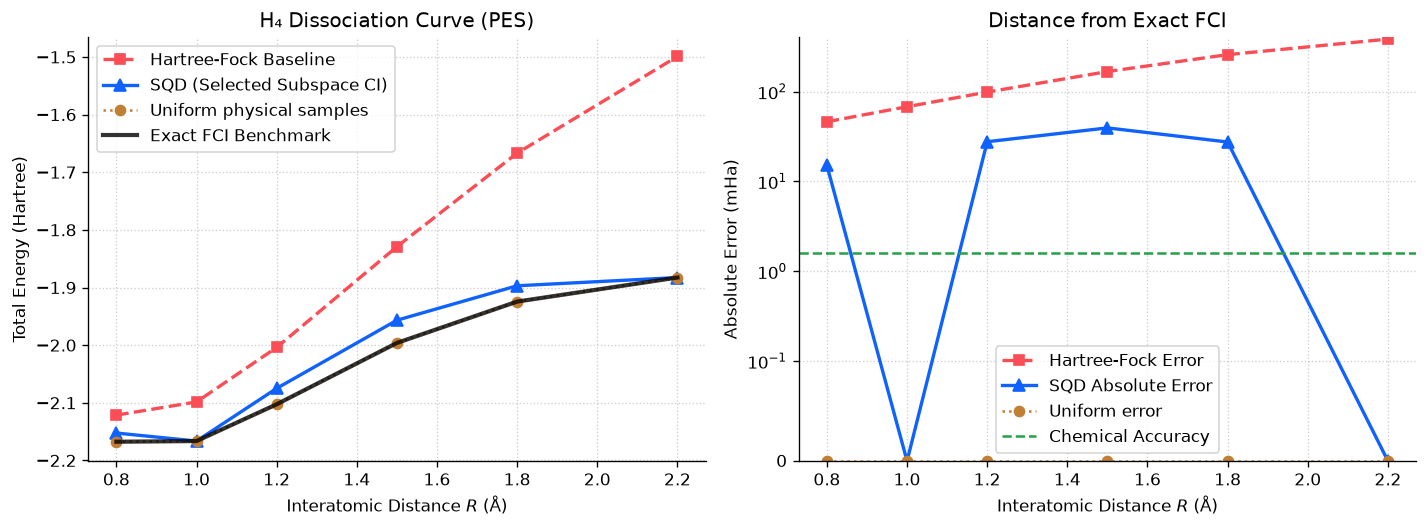

In [15]:
# Code Cell 7.2: H4 PES and Error Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: Potential energy curves
ax1.plot(distances, hf_energies, 's--', color='#fa4d56', lw=2, ms=6, label='Hartree-Fock Baseline')
ax1.plot(distances, sqd_energies, '^-', color='#0f62fe', lw=2, ms=7, label='SQD (Selected Subspace CI)')
ax1.plot(distances, uniform_energies, 'o:', color='#c07f35', lw=1.5, label='Uniform physical samples')
ax1.plot(distances, fci_energies, 'k-', lw=2.5, alpha=0.8, label='Exact FCI Benchmark')
ax1.set_xlabel("Interatomic Distance $R$ (\u00c5)")
ax1.set_ylabel("Total Energy (Hartree)")
ax1.set_title("H\u2084 Dissociation Curve (PES)")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()

# Panel 2: Absolute energy errors
signed_err_hf = (np.array(hf_energies) - np.array(fci_energies)) * 1000
signed_err_sqd = (np.array(sqd_energies) - np.array(fci_energies)) * 1000
abs_err_hf = np.abs(signed_err_hf)
abs_err_sqd = np.abs(signed_err_sqd)

ax2.plot(distances, abs_err_hf, 's--', color='#fa4d56', lw=2, ms=6, label='Hartree-Fock Error')
ax2.plot(distances, abs_err_sqd, '^-', color='#0f62fe', lw=2, ms=7, label='SQD Absolute Error')
ax2.plot(distances, np.abs(np.array(uniform_energies)-np.array(fci_energies))*1000, 'o:', color='#c07f35', label='Uniform error')
ax2.axhline(1.6, color='#24a148', linestyle='--', lw=1.5, label='Chemical Accuracy')
ax2.set_xlabel("Interatomic Distance $R$ (\u00c5)")
ax2.set_ylabel("Absolute Error (mHa)")
ax2.set_yscale("symlog", linthresh=1e-1)
ax2.set_ylim(bottom=0)
ax2.set_title("Distance from Exact FCI")
ax2.grid(True, which="both", linestyle=":", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

**How to read the curve:** the error plot is the important comparison. Use the printed determinant sizes to see whether accuracy came from a useful small subspace or a full-sector solve. This single-seed sweep is a teaching result; the festival study requires repeated seeds and controlled budgets.

## Part 8: Two controlled experiments
### Challenge 1 — synthetic readout flips
Reuse one clean circuit sample set, add per-bit readout flips at 0%, 1%, 5%, 10% and 20%, and hold solver settings constant. Measure particle-count acceptance, energy error and actual basis size.

A correct-count string can still be wrong. If noisy samples expand a tiny basis to all 36 determinants, exact energy reflects full-sector coverage, not restoration of the original state.


In [16]:
test_noise_rates = [0., .01, .05, .10, .20]
problem_c1 = build_active_space_problem(bond_distance=1.5)
ansatz_c1 = build_ansatz(problem_c1, amplitude_scale=1.)
_, counts_clean_c1 = sample_circuit(ansatz_c1, shots=1000, seed=150)
noise_results = []
print('Synthetic readout corruption; fixed 1,000 shots and 100 samples per batch')
for p in test_noise_rates:
    counts = add_bit_flip_noise(counts_clean_c1, p_flip=p, seed=150)
    retained = sum(count for string,count in counts.items()
                   if string[4:].count('1')==2 and string[:4].count('1')==2)
    result = recover_and_diagonalize(problem_c1, BitArray.from_counts(counts, num_bits=8),
        samples_per_batch=100, num_batches=1, max_iterations=4,
        symmetrize_spin=False, seed=42, verbose=False)
    row = dict(p_flip=p, valid_fraction=retained/1000,
               dimension=result['final_dimension'], error_mha=result['error_mha'])
    noise_results.append(row)
    print(f"p={p:.0%} | accepted={row['valid_fraction']:.1%} | M={row['dimension']} | error={row['error_mha']:+.4f} mHa")


Synthetic readout corruption; fixed 1,000 shots and 100 samples per batch
p=0% | accepted=100.0% | M=16 | error=+39.4143 mHa
p=1% | accepted=91.1% | M=20 | error=+38.7443 mHa
p=5% | accepted=68.5% | M=36 | error=+0.0000 mHa
p=10% | accepted=48.1% | M=36 | error=+0.0000 mHa
p=20% | accepted=27.2% | M=36 | error=+0.0000 mHa


**Read your output:** acceptance and energy accuracy are separate quantities. Compare the printed energy **and** dimension with the zero-noise row. A low error at dimension 36 means a full-sector solve. These five runs are a single-seed lesson, not a statistically established noise-robustness claim.


In this executed example, increased noise expands the returned basis until it includes all 36 determinants. That explains the exact energy: it is not evidence that extra noise improves the prepared quantum state.


### Challenge 2 — change batching while holding shots fixed
Take one fixed 1,000-shot dataset at R=1.2 Å. Compare 10, 30, 100 and 300 samples per batch, with the same solver seed and one batch.

This isolates a solver design choice. The original worksheet varied shots and batch size together; that cannot identify which caused a change. These returned bases are not guaranteed nested, so energy need not decrease monotonically.


In [17]:
problem_c2 = build_active_space_problem(bond_distance=1.2)
ansatz_c2 = build_ansatz(problem_c2, amplitude_scale=1.)
fixed_array_c2, fixed_counts_c2 = sample_circuit(ansatz_c2, shots=1000, seed=120)
batch_sizes = [10,30,100,300]
batch_results = []
for spb in batch_sizes:
    result = recover_and_diagonalize(problem_c2, fixed_array_c2,
        samples_per_batch=spb, num_batches=1, max_iterations=4,
        symmetrize_spin=False, seed=42, verbose=False)
    row = dict(samples_per_batch=spb, shots=1000, dimension=result['final_dimension'],
               energy=result['energy'], error_mha=result['error_mha'])
    batch_results.append(row)
    print(f"batch={spb:3} | fixed shots=1000 | M={row['dimension']:2} | error={row['error_mha']:+.4f} mHa")
assert sum(fixed_counts_c2.values())==1000


batch= 10 | fixed shots=1000 | M=12 | error=+41.0023 mHa
batch= 30 | fixed shots=1000 | M=12 | error=+41.0023 mHa
batch=100 | fixed shots=1000 | M=12 | error=+41.0023 mHa
batch=300 | fixed shots=1000 | M=12 | error=+41.0023 mHa


**Read your output:** a batch-size setting is not the number of unique determinants or the solve dimension. Repeated configurations and alpha/beta Cartesian expansion affect both. Higher batch size can discover useful configurations, but changing a non-nested selected basis provides no monotonicity guarantee. Use multiple seeds before making a comparative research claim.


Here all four batch settings return the same dimension and energy. Once the observed support is covered, asking for more samples in a batch can just repeat the same configurations.


### A quick control you can understand
Setting `amplitude_scale=0` removes the CCSD-informed excitations. It should leave the Hartree–Fock occupation string. We compare scales 0 and 1 at the same geometry, 256 shots and solver settings.

This checks that the control actually changes the circuit. A nonzero scale can help, but these parameters are not optimized to minimize the SQD energy.

**Coding detail:** always pass the circuit width to `BitArray.from_counts`. Leading zero bits still describe orbitals; automatic width inference can drop them when only the HF string is measured.

An exact local statevector checks the circuit itself; it is not used to generate the measured dataset. A 256-shot sample can miss low-probability configurations even when the circuit changed.


In [18]:
scale_results = []
control_problem = build_active_space_problem(bond_distance=1.0)
for scale in (0., 1.):
    diagnostic_state = Statevector.from_instruction(
        build_ansatz(control_problem, amplitude_scale=scale, measure=False))
    hf_probability = float(diagnostic_state.probabilities()[int('00110011', 2)])
    control_array, control_counts = sample_circuit(
        build_ansatz(control_problem, amplitude_scale=scale), shots=256, seed=314)
    if scale == 0:
        assert control_counts == {'00110011': 256}, 'Zero scale must leave HF'
    else:
        assert hf_probability < 1-1e-5, 'Nonzero scale must change the state'
    control_result = recover_and_diagonalize(control_problem, control_array,
        samples_per_batch=100, num_batches=1, max_iterations=4,
        symmetrize_spin=False, seed=42, verbose=False)
    row = dict(amplitude_scale=scale, shots=256, unique_strings=len(control_counts),
               hf_probability=hf_probability,
               dimension=control_result['final_dimension'], error_mha=control_result['error_mha'])
    scale_results.append(row)
    print(f"scale={scale:g} | HF probability={hf_probability:.4%} | unique={row['unique_strings']} | M={row['dimension']} | error={row['error_mha']:+.4f} mHa")
    if scale and len(control_counts) == 1:
        print('This seed missed all non-HF outcomes in 256 shots. Circuit change does not guarantee sampled-basis improvement.')
assert scale_results[0]['dimension'] == 1
assert abs(control_problem['e_hf']-control_problem['e_fci']-scale_results[0]['error_mha']/1000) < 1e-8


scale=0 | HF probability=100.0000% | unique=1 | M=1 | error=+67.8415 mHa
scale=1 | HF probability=98.7013% | unique=1 | M=1 | error=+67.8415 mHa
This seed missed all non-HF outcomes in 256 shots. Circuit change does not guarantee sampled-basis improvement.


## Part 9: All twelve answers in one place

| Exercise | Answer | Why |
|---|---|---|
| 1 | Computational Z basis | Samples give orbital occupations; matrix elements are evaluated classically |
| 2 | A `00110011`; B `00110110`; C `10011001`; D `11001100` | Read each spin register right-to-left, then pack beta + alpha |
| 3 | 256 mathematical strings; 36 physical determinants | `2**8` versus `comb(4,2)**2` |
| 4 | The FCI cell prints the computed count above 0.5%; 36 physical strings | Concentration depends on geometry and basis |
| 5 | `n_a=alpha.count('1')`, `n_b=beta.count('1')` | Keep the target counts; deduplicate only after counting accepted shots |
| 6 | Rank 4; direct coupling is zero | A one-/two-body Hamiltonian moves at most two electrons |
| 7 | Half the Hamming distance for equal-electron-number strings | One excitation removes one occupied bit and adds another |
| 8 | `retained / total`; `total - retained` | Count shots with multiplicities, not unique strings |
| 9 | Alpha 1, beta 2; rejected | `00110001` has three electrons rather than four |
| 10 | Call `recover_configurations(..., num_elec_a=2, num_elec_b=2, rand_seed=42)` | Enforce counts with occupation-guided proposals; verify normalized weights |
| 11 | `len(strs_a)*len(strs_b)` | The fermionic solver forms a Cartesian alpha/beta basis; symmetrization unions their string sets |
| 12 | Call the official driver with integrals, BitArray, `norb`, `nelec`, solver settings and callback | Add the nuclear/core offset exactly once; record final size and energy |

Fixing alpha/beta counts fixes electron number and spin projection $S_z$, **not** total-spin eigenvalue $S^2$. Spin-string symmetrization expands the basis; by itself it is not a full singlet projection.


## Part 10: A few things worth understanding

**Why can SQD beat the original circuit's energy?** The circuit proposes configurations. Classical diagonalization finds new amplitudes within their span, so it need not preserve the sampled state's original weights or phases.

**Why is the selected energy an upper bound?** We minimize over only some allowed states. The exact ground energy minimizes over the full physical sector. This assumes consistent integrals/offsets and an accurate solve; approximate numerical solvers have tolerances.

**Why do off-diagonal elements matter?** They couple different electron arrangements. Diagonalizing those couplings captures correlation; averaging diagonal energies does not perform SQD.

**Why use Davidson or other iterative solvers?** Large selected matrices can be expensive to store and diagonalize densely. Iterative methods approximate low eigenpairs using matrix-vector products and preconditioning. There is no universal 4–8 iteration or exponential-convergence guarantee.

**Does symmetry filtering repair noise?** It rejects wrong-count strings, but count-preserving errors survive. Recovery proposes physically allowed replacements; it cannot guarantee restoring lost information. Thermal relaxation is also not identical to our independent readout-bit-flip model.

**Does exact H4 energy establish advantage?** No. With only 36 physical configurations, uniform sampling can cover the entire sector. Compare actual dimensions, state-preparation work and classical solve costs, including strong classical selection methods.

### Try this next
Predict before running: set `amplitude_scale=0`. Which determinant should you measure? What happens to the selected dimension and energy? Then try one at the same small shot budget. Only the amplitude scale changes; keep geometry, shots and solver settings fixed.

Sources: [official SQD quickstart](https://qiskit.github.io/qiskit-addon-sqd/guides/quickstart.html), [ffsim UCJ](https://qiskit-community.github.io/ffsim/api/ffsim.html), [QSCI](https://arxiv.org/abs/2302.11320). This is a solved adaptation of the supplied Rishabh masterclass, not evidence of a newly invented algorithm.
